In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU - using CPU")

False
No GPU - using CPU


In [3]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

c:\Users\vvgk0135.DS\Desktop\mkdir medical-intent-classifier\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
df = pd.read_csv("../data/medquad_augmented.csv")

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["qtype"])

print(df[["qtype", "label"]].drop_duplicates().sort_values("label"))

                                        qtype  label
0                                      causes      0
3000                          exams and tests      1
6000                              information      2
9000                              inheritance      3
12000                                 outlook      4
15000                             precautions      5
18000                            side effects      6
21000                                symptoms      7
24000                               treatment      8
27000  when to contact a medical professional      9


In [9]:
import json

label_map = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
with open("../models/label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

print(label_map)

{'causes': 0, 'exams and tests': 1, 'information': 2, 'inheritance': 3, 'outlook': 4, 'precautions': 5, 'side effects': 6, 'symptoms': 7, 'treatment': 8, 'when to contact a medical professional': 9}


In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"]
)

print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 21000
Validation: 4500
Test: 4500


In [8]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=10
)

print("Tokenizer and model loaded")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6681.06it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer and model loaded


In [12]:
class MedicalIntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [13]:
train_dataset = MedicalIntentDataset(train_df["question"], train_df["label"], tokenizer)
val_dataset = MedicalIntentDataset(val_df["question"], val_df["label"], tokenizer)
test_dataset = MedicalIntentDataset(test_df["question"], test_df["label"], tokenizer)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 21000
Validation dataset size: 4500
Test dataset size: 4500


In [10]:
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print(f"Number of training batches: {len(train_loader)}")

Number of training batches: 2625


In [11]:
tiny_train = MedicalIntentDataset(
    train_df["question"].iloc[:50],
    train_df["label"].iloc[:50],
    tokenizer
)
tiny_loader = DataLoader(tiny_train, batch_size=8, shuffle=True)

batch = next(iter(tiny_loader))
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([8, 128])
torch.Size([8, 128])
torch.Size([8])


In [12]:
df["word_count"] = df["question"].str.split().str.len()
print(df["word_count"].describe())

count    30000.000000
mean         7.939733
std          2.523988
min          2.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         24.000000
Name: word_count, dtype: float64


In [13]:
MAX_LENGTH = 64

train_dataset = MedicalIntentDataset(train_df["question"], train_df["label"], tokenizer, max_length=MAX_LENGTH)
val_dataset = MedicalIntentDataset(val_df["question"], val_df["label"], tokenizer, max_length=MAX_LENGTH)
test_dataset = MedicalIntentDataset(test_df["question"], test_df["label"], tokenizer, max_length=MAX_LENGTH)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Datasets rebuilt with max_length=64")

Datasets rebuilt with max_length=64


In [14]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)
device = torch.device("cpu")
model.to(device)

print(f"Model moved to {device}")

Model moved to cpu


In [15]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    return avg_loss

In [16]:
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [17]:
EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, device)
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}")


Epoch 1/3


Evaluating: 100%|██████████| 563/563 [01:15<00:00,  7.42it/s]


Train Loss: 0.0563 | Val Loss: 0.0030 | Val Accuracy: 0.9993

Epoch 2/3


Evaluating: 100%|██████████| 563/563 [01:13<00:00,  7.62it/s]


Train Loss: 0.0135 | Val Loss: 0.1616 | Val Accuracy: 0.9284

Epoch 3/3


Evaluating: 100%|██████████| 563/563 [01:15<00:00,  7.49it/s]

Train Loss: 0.0085 | Val Loss: 0.0041 | Val Accuracy: 0.9991


In [18]:
model.save_pretrained("../models/distilbert_medical_intent")
tokenizer.save_pretrained("../models/distilbert_medical_intent")
print("Model and tokenizer saved")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.48it/s]

Model and tokenizer saved


In [19]:
test_queries = [
    "what does it mean if i have this thing in my family history",
    "is this gonna kill me or am i overreacting",
    "my chest feels tight and heavy should i worry",
    "can my kids catch this from me",
    "wat is this thing even called",
]

model.eval()
for query in test_queries:
    inputs = tokenizer(
        query,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=64
    )
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = torch.softmax(outputs.logits, dim=1)
    confidence = probs.max().item()
    pred_label = probs.argmax().item()
    pred_class = label_encoder.inverse_transform([pred_label])[0]
    
    print(f"Query: {query}")
    print(f"Prediction: {pred_class} (confidence: {confidence:.2%})\n")

Query: what does it mean if i have this thing in my family history
Prediction: symptoms (confidence: 99.99%)

Query: is this gonna kill me or am i overreacting
Prediction: inheritance (confidence: 99.93%)

Query: my chest feels tight and heavy should i worry
Prediction: symptoms (confidence: 80.81%)

Query: can my kids catch this from me
Prediction: information (confidence: 61.50%)

Query: wat is this thing even called
Prediction: information (confidence: 99.86%)



In [2]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json

# Load model + tokenizer from disk
model = AutoModelForSequenceClassification.from_pretrained("../models/distilbert_medical_intent")
tokenizer = AutoTokenizer.from_pretrained("../models/distilbert_medical_intent")
device = torch.device("cpu")
model.to(device)

# Load label map
with open("../models/distilbert_medical_intent/label_map.json", "r") as f:
    label_map = json.load(f)
label_encoder = LabelEncoder()
label_encoder.classes_ = list(label_map.keys())

# Load the EXACT test split that was used during training on Aire
test_df = pd.read_csv("../models/distilbert_medical_intent/test_split.csv")

print(f"Model loaded. Test set: {len(test_df)} examples")
print(test_df["qtype"].value_counts())

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6013.50it/s]

Model loaded. Test set: 4500 examples
qtype
information                               450
exams and tests                           450
symptoms                                  450
inheritance                               450
when to contact a medical professional    450
side effects                              450
causes                                    450
outlook                                   450
precautions                               450
treatment                                 450
Name: count, dtype: int64


In [5]:
class MedicalIntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text, truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

test_df["label"] = label_encoder.transform(test_df["qtype"])
test_dataset = MedicalIntentDataset(test_df["question"], test_df["label"], tokenizer)
test_loader = DataLoader(test_dataset, batch_size=8)

print(f"Test batches: {len(test_loader)}")

Test batches: 563


In [4]:
import numpy as np

label_encoder.classes_ = np.array(list(label_map.keys()))

In [6]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Done")

Testing: 100%|██████████| 563/563 [01:10<00:00,  7.98it/s]

Done


In [7]:
pred_labels = label_encoder.inverse_transform(all_preds)
true_labels = label_encoder.inverse_transform(all_labels)

print(classification_report(true_labels, pred_labels))

                                        precision    recall  f1-score   support

                                causes       1.00      1.00      1.00       450
                       exams and tests       1.00      1.00      1.00       450
                           information       1.00      1.00      1.00       450
                           inheritance       1.00      1.00      1.00       450
                               outlook       1.00      1.00      1.00       450
                           precautions       1.00      1.00      1.00       450
                          side effects       1.00      1.00      1.00       450
                              symptoms       1.00      1.00      1.00       450
                             treatment       1.00      1.00      1.00       450
when to contact a medical professional       1.00      1.00      1.00       450

                              accuracy                           1.00      4500
                             macro avg

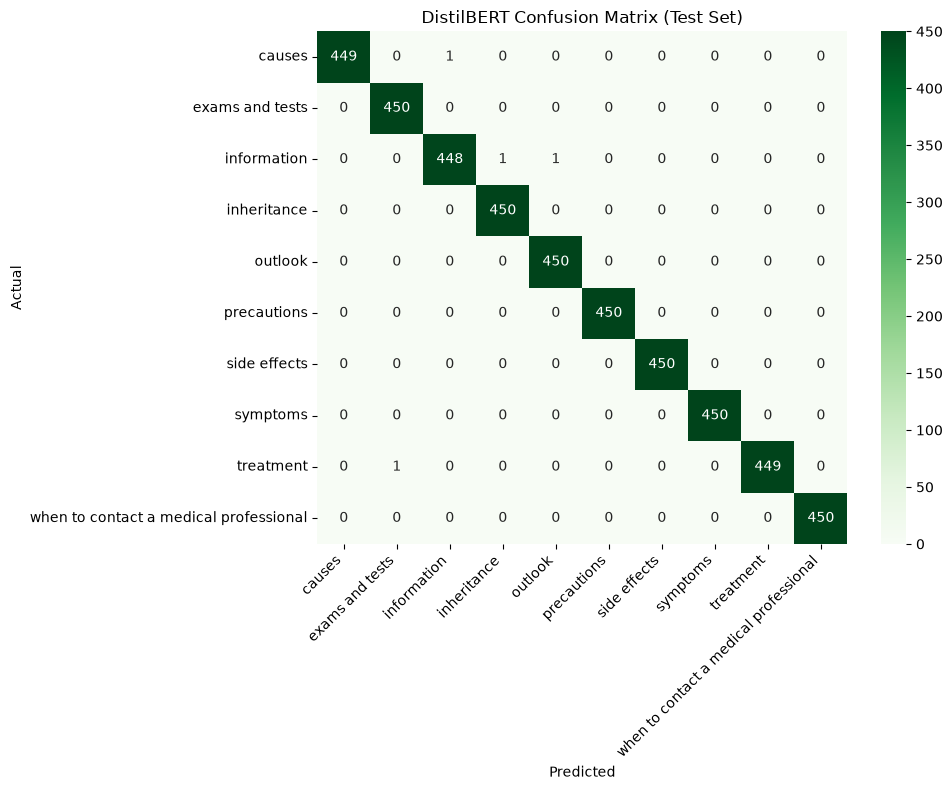

In [8]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_labels, pred_labels, labels=label_encoder.classes_)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../models/distilbert_confusion_matrix.png", dpi=150)
plt.show()

In [9]:
stress_test = [
    # causes
    {"question": "why does this keep happening to me", "true_label": "causes"},
    {"question": "is this something i did to myself", "true_label": "causes"},
    
    # inheritance
    {"question": "can my kids catch this from me", "true_label": "inheritance"},
    {"question": "did i get this from my mum", "true_label": "inheritance"},
]

stress_df = pd.DataFrame(stress_test)
print(stress_df)

                             question   true_label
0  why does this keep happening to me       causes
1   is this something i did to myself       causes
2      can my kids catch this from me  inheritance
3          did i get this from my mum  inheritance


In [10]:
stress_test = [
    {"question": "why does this keep happening to me", "true_label": "causes"},
    {"question": "is this something i did to myself", "true_label": "causes"},
    {"question": "could stress be behind all this", "true_label": "causes"},
    {"question": "what's actually triggering this", "true_label": "causes"},
    {"question": "is it something in my diet doing this", "true_label": "causes"},

    {"question": "what kind of test will they do to check this", "true_label": "exams and tests"},
    {"question": "do i need a scan or just bloods", "true_label": "exams and tests"},
    {"question": "how will the doctor figure out what's wrong", "true_label": "exams and tests"},
    {"question": "is there a way to check this at home first", "true_label": "exams and tests"},
    {"question": "will they need to take a sample to know for sure", "true_label": "exams and tests"},

    {"question": "wat is this thing even called", "true_label": "information"},
    {"question": "never heard of this before what even is it", "true_label": "information"},
    {"question": "can someone just explain this to me simply", "true_label": "information"},
    {"question": "is this the same as the flu or something else", "true_label": "information"},
    {"question": "googled my symptoms and this came up, what is it", "true_label": "information"},

    {"question": "can my kids catch this from me", "true_label": "inheritance"},
    {"question": "did i get this from my mum", "true_label": "inheritance"},
    {"question": "what does it mean if i have this thing in my family history", "true_label": "inheritance"},
    {"question": "is this passed down or just bad luck", "true_label": "inheritance"},
    {"question": "should my siblings get checked too because of me", "true_label": "inheritance"},

    {"question": "is this gonna kill me or am i overreacting", "true_label": "outlook"},
    {"question": "will i ever be normal again after this", "true_label": "outlook"},
    {"question": "how long do people usually live with this", "true_label": "outlook"},
    {"question": "does this get better with time or worse", "true_label": "outlook"},
    {"question": "am i going to need to deal with this forever", "true_label": "outlook"},

    {"question": "what should i avoid doing while i have this", "true_label": "precautions"},
    {"question": "is it safe for me to go to work like this", "true_label": "precautions"},
    {"question": "should i be staying away from people right now", "true_label": "precautions"},
    {"question": "can i still exercise with this going on", "true_label": "precautions"},
    {"question": "what's the best way to stop this getting worse", "true_label": "precautions"},

    {"question": "is feeling sick normal after starting this medicine", "true_label": "side effects"},
    {"question": "why do i feel worse since taking the tablets", "true_label": "side effects"},
    {"question": "will this medication mess with my sleep", "true_label": "side effects"},
    {"question": "is the dizziness from the new pills i started", "true_label": "side effects"},
    {"question": "should i be worried about this reaction i'm having", "true_label": "side effects"},

    {"question": "my chest feels tight and heavy should i worry", "true_label": "symptoms"},
    {"question": "i keep feeling dizzy when i stand up too fast", "true_label": "symptoms"},
    {"question": "is it normal to feel this exhausted all the time", "true_label": "symptoms"},
    {"question": "why does my stomach hurt after i eat anything", "true_label": "symptoms"},
    {"question": "i've had this weird tingling for days is that bad", "true_label": "symptoms"},

    {"question": "how do they actually fix this kind of thing", "true_label": "treatment"},
    {"question": "is surgery the only option here", "true_label": "treatment"},
    {"question": "will i need to be on medication for life", "true_label": "treatment"},
    {"question": "what happens if i just leave it untreated", "true_label": "treatment"},
    {"question": "are there other options besides what they gave me", "true_label": "treatment"},

    {"question": "should i be worried enough to go to a and e", "true_label": "when to contact a medical professional"},
    {"question": "is this serious enough to call 111", "true_label": "when to contact a medical professional"},
    {"question": "do i need to see someone today or can it wait", "true_label": "when to contact a medical professional"},
    {"question": "at what point should i actually go to hospital", "true_label": "when to contact a medical professional"},
    {"question": "is this an emergency or am i just panicking", "true_label": "when to contact a medical professional"},
]

stress_df = pd.DataFrame(stress_test)
stress_df.to_csv("../data/stress_test.csv", index=False)
print(f"Stress test set: {len(stress_df)} examples")
print(stress_df["true_label"].value_counts())

Stress test set: 50 examples
true_label
causes                                    5
exams and tests                           5
information                               5
inheritance                               5
outlook                                   5
precautions                               5
side effects                              5
symptoms                                  5
treatment                                 5
when to contact a medical professional    5
Name: count, dtype: int64


In [11]:
model.eval()
stress_results = []

for _, row in stress_df.iterrows():
    inputs = tokenizer(
        row["question"], return_tensors="pt", truncation=True,
        padding="max_length", max_length=64
    )
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    confidence = probs.max().item()
    pred_idx = probs.argmax().item()
    pred_label = label_encoder.inverse_transform([pred_idx])[0]

    stress_results.append({
        "question": row["question"],
        "true_label": row["true_label"],
        "predicted": pred_label,
        "confidence": confidence,
        "correct": pred_label == row["true_label"]
    })

stress_results_df = pd.DataFrame(stress_results)
accuracy = stress_results_df["correct"].mean()
print(f"Stress test accuracy: {accuracy:.2%}")
print(f"\nCorrect: {stress_results_df['correct'].sum()} / {len(stress_results_df)}")

Stress test accuracy: 18.00%

Correct: 9 / 50


In [12]:
pd.set_option("display.max_colwidth", 100)
wrong = stress_results_df[~stress_results_df["correct"]]
print(f"Wrong: {len(wrong)} / 50\n")
print(wrong[["question", "true_label", "predicted", "confidence"]].to_string(index=False))

Wrong: 41 / 50

                                                   question                             true_label                              predicted  confidence
                          is this something i did to myself                                 causes                            information    0.966942
                            could stress be behind all this                                 causes                            information    0.943753
                            what's actually triggering this                                 causes                            information    0.993133
                      is it something in my diet doing this                                 causes                            information    0.818416
               what kind of test will they do to check this                        exams and tests                               symptoms    0.600109
                            do i need a scan or just bloods                        e

In [13]:
import lime
print("LIME already installed")

LIME already installed


In [14]:
from lime.lime_text import LimeTextExplainer

class_names = list(label_encoder.classes_)

def predict_proba(texts):
    """LIME needs a function that takes raw text and returns class probabilities."""
    results = []
    for text in texts:
        inputs = tokenizer(
            text, return_tensors="pt", truncation=True,
            padding="max_length", max_length=64
        )
        with torch.no_grad():
            outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).numpy()[0]
        results.append(probs)
    return np.array(results)

explainer = LimeTextExplainer(class_names=class_names)

text_to_explain = "can my kids catch this from me"
explanation = explainer.explain_instance(
    text_to_explain, predict_proba, num_features=10, num_samples=200
)

explanation.show_in_notebook(text=True)

ImportError: cannot import name 'display' from 'IPython.core.display' (c:\Users\vvgk0135.DS\Desktop\mkdir medical-intent-classifier\venv\Lib\site-packages\IPython\core\display.py)

In [15]:
print(f"Predicted class: {class_names[explanation.available_labels()[0]]}\n")

for label_idx in explanation.available_labels():
    print(f"\n--- Explanation for class: {class_names[label_idx]} ---")
    for word, weight in explanation.as_list(label=label_idx):
        print(f"  {word:15s} {weight:+.4f}")

Predicted class: exams and tests


--- Explanation for class: exams and tests ---
  this            -0.0189
  kids            -0.0188
  can             +0.0178
  from            -0.0167
  catch           -0.0137
  me              -0.0074
  my              -0.0073


In [16]:
inputs = tokenizer(
    "can my kids catch this from me", return_tensors="pt",
    truncation=True, padding="max_length", max_length=64
)
with torch.no_grad():
    outputs = model(**inputs)
probs = torch.softmax(outputs.logits, dim=1)
top_idx = probs.argmax().item()
print(f"Predicted: {class_names[top_idx]} ({probs.max().item():.2%})")

# show all class probabilities sorted
for idx in probs[0].argsort(descending=True):
    print(f"  {class_names[idx]:45s} {probs[0][idx].item():.4f}")

Predicted: information (98.81%)
  information                                   0.9881
  causes                                        0.0043
  symptoms                                      0.0027
  treatment                                     0.0012
  exams and tests                               0.0011
  outlook                                       0.0010
  side effects                                  0.0005
  inheritance                                   0.0005
  when to contact a medical professional        0.0003
  precautions                                   0.0002


In [17]:
info_idx = list(class_names).index("information")

explanation = explainer.explain_instance(
    "can my kids catch this from me", predict_proba,
    num_features=10, num_samples=300, labels=[info_idx]
)

print(f"--- Why the model predicted 'information' ---\n")
for word, weight in explanation.as_list(label=info_idx):
    print(f"  {word:15s} {weight:+.4f}")

--- Why the model predicted 'information' ---

  this            +0.3353
  my              +0.3198
  kids            -0.2678
  catch           -0.0670
  can             +0.0508
  from            +0.0348
  me              -0.0229


In [18]:
causes_idx = list(class_names).index("causes")

explanation = explainer.explain_instance(
    "is this gonna kill me or am i overreacting", predict_proba,
    num_features=10, num_samples=300, labels=[causes_idx]
)

print(f"--- Why the model predicted 'causes' ---\n")
for word, weight in explanation.as_list(label=causes_idx):
    print(f"  {word:15s} {weight:+.4f}")

--- Why the model predicted 'causes' ---

  kill            +0.1997
  or              +0.1748
  this            -0.1380
  am              -0.1344
  me              +0.1332
  gonna           +0.1050
  overreacting    +0.0918
  i               -0.0594
  is              +0.0580
